# **Day 23: Gradient Descent and Polynomial Regression**
*Module 4 - Regression*

OLS has a closed form, but it costs $O(np^2 + p^3)$ and needs all data in memory. **Gradient descent** scales to millions of samples and is the same algorithm that trains neural networks. Today we build a linear-regression class from scratch, compare batch/stochastic/mini-batch GD, then extend linear models to curves with **polynomial regression**.

> Gradient descent finds the regression line step by step instead of with a formula, which also works for very large data. Polynomial regression bends the line into a curve, but too high a degree starts fitting noise.
>
> *Example:* The NDVI-biomass relation flattens at high biomass. A degree-2 curve captures this; a degree-15 curve wiggles through every noisy point and predicts badly on new plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(23)

## **1. Linear Regression by Gradient Descent**
Loss (MSE): $J(\mathbf w, b) = \frac{1}{n}\sum_i(\mathbf w^\top\mathbf x_i + b - y_i)^2$
Gradients: $\nabla_{\mathbf w}J = \frac{2}{n}X^\top(X\mathbf w + b - \mathbf y)$, $\;\partial_b J = \frac{2}{n}\sum_i(\hat y_i - y_i)$

In [2]:
class LinearRegressionGD:
    def __init__(self, lr=0.05, n_epochs=1000, batch_size=None, seed=0, tol=1e-10):
        self.lr, self.n_epochs, self.batch_size, self.seed, self.tol = lr, n_epochs, batch_size, seed, tol

    def fit(self, X, y):
        r = np.random.default_rng(self.seed)
        n, p = X.shape
        self.w_, self.b_ = np.zeros(p), 0.0
        self.loss_history_ = []
        bs = self.batch_size or n
        for epoch in range(self.n_epochs):
            idx = r.permutation(n)
            for start in range(0, n, bs):
                b_idx = idx[start:start + bs]
                err = X[b_idx] @ self.w_ + self.b_ - y[b_idx]
                self.w_ -= self.lr * 2 / len(b_idx) * X[b_idx].T @ err
                self.b_ -= self.lr * 2 * err.mean()
            loss = np.mean((X @ self.w_ + self.b_ - y) ** 2)
            self.loss_history_.append(loss)
            if epoch > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                break
        return self

    def predict(self, X):
        return X @ self.w_ + self.b_

n, p = 2000, 5
X = rng.normal(size=(n, p)); w_true = np.array([3.0, -2.0, 0.5, 0.0, 1.5])
y = X @ w_true + 4.0 + rng.normal(0, 0.5, n)
gd = LinearRegressionGD(lr=0.05).fit(X, y)
from sklearn.linear_model import LinearRegression
ols = LinearRegression().fit(X, y)
print("GD  w:", gd.w_.round(3), "b:", round(gd.b_, 3), f"({len(gd.loss_history_)} epochs)")
print("OLS w:", ols.coef_.round(3), "b:", round(ols.intercept_, 3))

GD  w: [ 3.014 -1.998  0.483 -0.021  1.509] b: 3.985 (123 epochs)
OLS w: [ 3.014 -1.998  0.483 -0.021  1.509] b: 3.985


## **2. Batch vs Stochastic vs Mini-Batch**

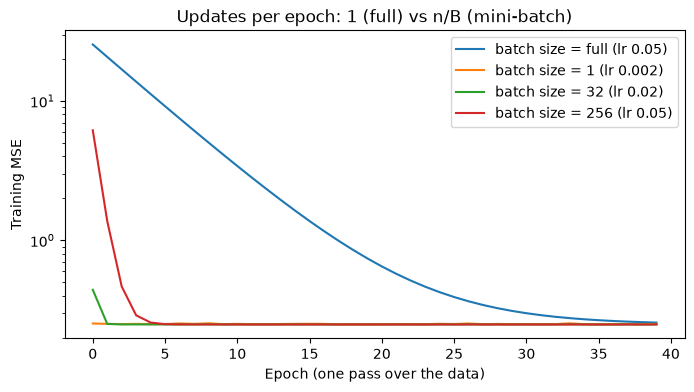

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for bs, lr in [(None, 0.05), (1, 0.002), (32, 0.02), (256, 0.05)]:
    m = LinearRegressionGD(lr=lr, n_epochs=40, batch_size=bs, tol=0).fit(X, y)
    ax.semilogy(m.loss_history_, label=f"batch size = {bs or 'full'} (lr {lr})")
ax.set_xlabel("Epoch (one pass over the data)"); ax.set_ylabel("Training MSE"); ax.legend(); ax.set_title("Updates per epoch: 1 (full) vs n/B (mini-batch)")
plt.show()

Per **epoch**, mini-batch GD makes many more updates and converges faster; SGD (batch 1) is noisy and needs a small learning rate.

## **3. Feature Scaling Matters for GD**

In [4]:
X_bad = X * np.array([1, 10, 100, 1, 0.1])                # wildly different scales
for name, Xm in [("unscaled", X_bad), ("standardised", (X_bad - X_bad.mean(0)) / X_bad.std(0))]:
    lr_max = 0.9 / np.linalg.eigvalsh(2 / n * Xm.T @ Xm).max()   # stable step size bound
    m = LinearRegressionGD(lr=lr_max, n_epochs=3000).fit(Xm, y)
    print(f"{name:<13} stable lr ~ {lr_max:.2e}, epochs to converge: {len(m.loss_history_)}, final MSE {m.loss_history_[-1]:.4f}")

unscaled      stable lr ~ 4.57e-05, epochs to converge: 3000, final MSE 16.8905
standardised  stable lr ~ 4.28e-01, epochs to converge: 9, final MSE 0.2483


## **4. scikit-learn's SGDRegressor**
Supports regularisation, learning-rate schedules and `partial_fit` for streaming data.

In [5]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
sgd = make_pipeline(StandardScaler(), SGDRegressor(max_iter=1000, tol=1e-6, random_state=0)).fit(X, y)
print("SGDRegressor w:", sgd[-1].coef_.round(3), "b:", sgd[-1].intercept_.round(3))

SGDRegressor w: [ 3.008 -1.993  0.48  -0.026  1.513] b: [3.966]


## **5. Polynomial Regression**
A linear model in **transformed features** $[x, x^2, \dots, x^d]$ can fit curves. It is still "linear" (linear in the parameters), so OLS and all of Day 22's theory apply.

Example: the response of crop yield to nitrogen fertiliser is concave (diminishing returns, then toxicity).

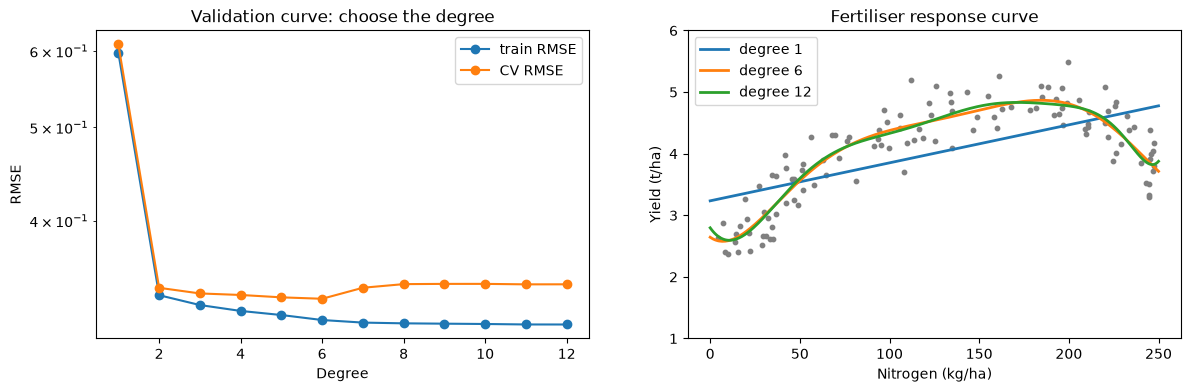

Best degree by CV: 6


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import validation_curve, cross_val_score

N = rng.uniform(0, 250, 120)
yld = 2 + 0.035 * N - 0.00011 * N ** 2 + rng.normal(0, 0.35, 120)
degrees = np.arange(1, 13)
train_sc, val_sc = validation_curve(make_pipeline(PolynomialFeatures(), StandardScaler(), LinearRegression()),
                                    N[:, None], yld, param_name="polynomialfeatures__degree", param_range=degrees,
                                    cv=5, scoring="neg_root_mean_squared_error")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(degrees, -train_sc.mean(1), "o-", label="train RMSE"); axes[0].plot(degrees, -val_sc.mean(1), "o-", label="CV RMSE")
axes[0].set(xlabel="Degree", ylabel="RMSE", title="Validation curve: choose the degree", yscale="log"); axes[0].legend()
best_deg = degrees[np.argmax(val_sc.mean(1))]
grid = np.linspace(0, 250, 300)[:, None]
axes[1].scatter(N, yld, s=10, c="grey")
for d in [1, best_deg, 12]:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(N[:, None], yld)
    axes[1].plot(grid, m.predict(grid), lw=2, label=f"degree {d}")
axes[1].set(xlabel="Nitrogen (kg/ha)", ylabel="Yield (t/ha)", title="Fertiliser response curve", ylim=(1, 6)); axes[1].legend()
plt.show()
print("Best degree by CV:", best_deg)

### Economic optimum from the fitted curve
With the quadratic model $y = a + bN + cN^2$, maximum yield is at $N^* = -b/(2c)$. If fertiliser costs $p_N$ per kg and grain sells at $p_y$ per t, profit is maximised where the marginal product equals the price ratio: $b + 2cN = p_N/p_y$.

In [7]:
quad = LinearRegression().fit(np.c_[N, N ** 2], yld)
b_, c_ = quad.coef_
print(f"Agronomic optimum: N* = {-b_ / (2 * c_):.0f} kg/ha")
p_N, p_y = 25, 20000                                   # Rs per kg N, Rs per t grain
print(f"Economic optimum : N  = {(p_N / p_y - b_) / (2 * c_):.0f} kg/ha")

Agronomic optimum: N* = 159 kg/ha
Economic optimum : N  = 153 kg/ha


### Polynomial pitfalls
- **Extrapolation**: high-degree polynomials explode outside the data range.
- **Runge's phenomenon**: oscillations near the edges.
- **Ill-conditioning**: $x^{10}$ for $x\sim 200$ is $10^{23}$. Always scale (or use splines, Day 19).

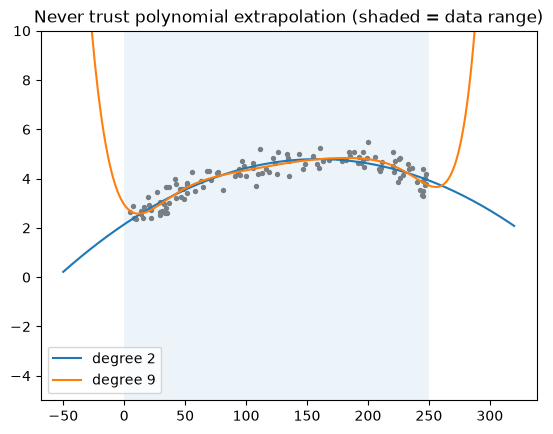

In [8]:
grid_ext = np.linspace(-50, 320, 300)[:, None]
for d in [2, 9]:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(N[:, None], yld)
    plt.plot(grid_ext, m.predict(grid_ext), label=f"degree {d}")
plt.scatter(N, yld, s=8, c="grey"); plt.axvspan(0, 250, alpha=0.08); plt.ylim(-5, 10)
plt.legend(); plt.title("Never trust polynomial extrapolation (shaded = data range)"); plt.show()

# **Part 2: Going Deeper - Online Learning**

When data arrive as a stream or do not fit in memory, `partial_fit` updates the model batch by batch.

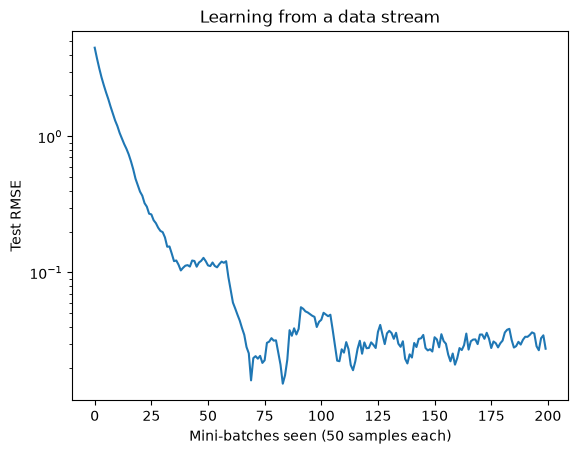

In [9]:
online = SGDRegressor(learning_rate="invscaling", eta0=0.01, random_state=0)
scaler = StandardScaler()
errs = []
X_test_stream = rng.normal(size=(1000, p)); y_test_stream = X_test_stream @ w_true + 4
for step in range(200):
    Xb = rng.normal(size=(50, p)); yb = Xb @ w_true + 4 + rng.normal(0, 0.5, 50)
    scaler.partial_fit(Xb)
    online.partial_fit(scaler.transform(Xb), yb)
    errs.append(np.sqrt(np.mean((online.predict(scaler.transform(X_test_stream)) - y_test_stream) ** 2)))
plt.semilogy(errs); plt.xlabel("Mini-batches seen (50 samples each)"); plt.ylabel("Test RMSE"); plt.title("Learning from a data stream"); plt.show()

| | Closed form (normal equations / QR) | Gradient descent |
|---|---|---|
| Cost | $O(np^2 + p^3)$ | $O(np)$ per epoch |
| Memory | All data | One batch |
| Hyperparameters | None | Learning rate, epochs, batch size |
| Best for | $p$ < ~10,000, data fits in memory | Huge $n$ or $p$, streaming, neural nets |

## **Practice Problems**
1. Add an L2 penalty $\lambda\lVert\mathbf w\rVert^2$ to `LinearRegressionGD` (Ridge by GD). Check against `Ridge(alpha=...)` (careful: sklearn's Ridge minimises $\lVert y - Xw\rVert^2 + \alpha\lVert w\rVert^2$, not the mean).
2. Implement early stopping: stop when the **validation** loss has not improved for 10 epochs.
3. Fit a degree-2 polynomial in **two** features `(N, P)` and print the feature names.
4. *(Advanced)* Time `LinearRegression` vs our GD for n = 200,000, p = 50.

In [10]:
# Solution 1
class RidgeGD(LinearRegressionGD):
    def __init__(self, lam=1.0, **kw):
        super().__init__(**kw); self.lam = lam
    def fit(self, X, y):
        n_, p_ = X.shape; self.w_, self.b_ = np.zeros(p_), 0.0
        for _ in range(self.n_epochs):
            err = X @ self.w_ + self.b_ - y
            self.w_ -= self.lr * (2 / n_ * X.T @ err + 2 * self.lam / n_ * self.w_)
            self.b_ -= self.lr * 2 * err.mean()
        return self
from sklearn.linear_model import Ridge
print("RidgeGD:", RidgeGD(lam=500, lr=0.05, n_epochs=3000).fit(X, y).w_.round(3))
print("sklearn:", Ridge(alpha=500).fit(X, y).coef_.round(3))
# Solution 2
Xtr, Xva, ytr, yva = X[:1500], X[1500:], y[:1500], y[1500:]
w, b, best, wait, hist = np.zeros(p), 0.0, np.inf, 0, []
for epoch in range(1000):
    err = Xtr @ w + b - ytr; w -= 0.01 * 2 / len(ytr) * Xtr.T @ err; b -= 0.01 * 2 * err.mean()
    vl = np.mean((Xva @ w + b - yva) ** 2); hist.append(vl)
    if vl < best - 1e-6: best, wait = vl, 0
    else:
        wait += 1
        if wait >= 10: break
print(f"stopped at epoch {epoch}, best val MSE {best:.4f}")
# Solution 3
pf = PolynomialFeatures(2).fit(np.c_[N, N]); print(pf.get_feature_names_out(["N", "P"]))
# Solution 4
import time
Xbig = rng.normal(size=(200_000, 50)); ybig = Xbig @ rng.normal(size=50) + rng.normal(size=200_000)
t0 = time.perf_counter(); LinearRegression().fit(Xbig, ybig); t1 = time.perf_counter()
LinearRegressionGD(lr=0.1, n_epochs=50, batch_size=1024).fit(Xbig, ybig); t2 = time.perf_counter()
print(f"OLS {t1 - t0:.2f}s | mini-batch GD (50 epochs) {t2 - t1:.2f}s")

RidgeGD: [ 2.399 -1.584  0.378 -0.026  1.213]
sklearn: [ 2.399 -1.584  0.378 -0.026  1.213]
stopped at epoch 311, best val MSE 0.2560
['1' 'N' 'P' 'N^2' 'N P' 'P^2']


OLS 0.23s | mini-batch GD (50 epochs) 1.82s


## **Key References**
- Bottou, L. (2010). Large-scale machine learning with stochastic gradient descent. *COMPSTAT 2010*, 177-186.
- Robbins, H., & Monro, S. (1951). A stochastic approximation method. *The Annals of Mathematical Statistics*, 22(3), 400-407.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 7. Springer.